In [5]:
import pandas as pd
import json
import seaborn as sns

In [2]:
dados = pd.read_json('informacoes.json')
dados

,nome,idade,enderecos
0,João,28,"{'tipo': 'casa', 'rua': 'Rua A', 'numero': 123..."
1,João,28,"{'tipo': 'trabalho', 'rua': 'Rua B', 'numero':..."


In [3]:
with open('informacoes.json',encoding='UTF-8') as f:
    json = json.load(f)
json

{'nome': 'João',
 'idade': 28,
 'enderecos': [{'tipo': 'casa',
   'rua': 'Rua A',
   'numero': 123,
   'cidade': 'São Paulo'},
  {'tipo': 'trabalho',
   'rua': 'Rua B',
   'numero': 456,
   'cidade': 'Rio de Janeiro'}]}

In [4]:
dados = pd.json_normalize(json,record_path='enderecos',meta=['nome','idade'],errors='ignore')
dados

,tipo,rua,numero,cidade,nome,idade
0,casa,Rua A,123,São Paulo,João,28
1,trabalho,Rua B,456,Rio de Janeiro,João,28


<h1>Sua tarefa é realizar alguns tratamentos e deixar esse arquivo JSON como um Pandas DataFrame, sem dados vazios e com a tipagem das colunas de forma correta. </h1>

In [5]:
dados_2 = pd.read_json('dados.json')
dados_2

,pessoas
0,"{'nome': 'João', 'idade': '25', 'endereco': {'..."
1,"{'nome': 'Maria', 'idade': 30, 'endereco': {'r..."


In [6]:
dados_2 = pd.json_normalize(dados_2['pessoas'])
#dados_2 = dados_2.explode('telefones',ignore_index=True)

In [7]:
dados_2

,nome,idade,telefones,endereco.rua,endereco.numero,endereco.cidade
0,João,25,"[11 1111-1111, 11 2222-2222]",Rua A,123,São Paulo
1,Maria,30,[21 3333-3333],,456,Rio de Janeiro


In [8]:
dados_2 = dados_2.query('`endereco.rua` != ""')
dados_2

,nome,idade,telefones,endereco.rua,endereco.numero,endereco.cidade
0,João,25,"[11 1111-1111, 11 2222-2222]",Rua A,123,São Paulo


dados_2.info()

In [9]:
dados_2['idade'] = dados['idade'].astype('int32')

In [10]:
dados_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   nome             1 non-null      str   
 1   idade            1 non-null      int32 
 2   telefones        1 non-null      object
 3   endereco.rua     1 non-null      str   
 4   endereco.numero  1 non-null      int64 
 5   endereco.cidade  1 non-null      str   
dtypes: int32(1), int64(1), object(1), str(3)
memory usage: 176.0+ bytes


<h3>Valores nulos: são valores ausentes em algumas das colunas que devem ser preenchidos para que a análise seja correta.

    

Duplicatas: registros iguais que podem prejudicar a análise dos dados, já que estão representando a mesma informação.

Strings vazias: valores de texto que não apresentam nenhum conteúdo escrito, o que pode dificultar a análise de dados, principalmente se a coluna tiver muitos valores assim.

Conversão de tipos: algumas colunas do arquivo podem estar no tipo de dados errado, como texto em vez de número, o que pode prejudicar a análise. Nesse caso você deve realizar a conversão para o tipo 
correto de cada coluna.</h3>

In [11]:
cursos = pd.read_json('cursos_cadastrados.json')
cursos

,curso,categoria,carga_horaria,concluintes,data_inicio,data_conclusao,descricao,preco,instrutor
0,Introdução à programação,Programação,20 horas,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,"{'nome': 'João Silva', 'email': 'joao.silva@em..."
1,Excel para iniciantes,Produtividade,NaN,None,NaN,NaN,NaN,NaN,"{'nome': 'Maria Oliveira', 'email': 'maria.oli..."
2,Marketing digital para negócios,Marketing,30 horas,75,2022-03-01,2022-03-31,Curso introdutório em marketing,89.9,"{'nome': 'Ana Santos', 'email': 'ana.santos@em..."
3,Inteligência artificial,Programação,40 horas,,2022-04-01,,Curso avançado sobre inteligência artificial c...,129.9,"{'nome': '', 'email': 'contato@emailaleatorio...."
4,Inglês para negócios,Idiomas,20 horas,30,,,Curso de inglês para negócios,69.9,"{'nome': 'John Smith', 'email': '', 'telefone'..."
5,Introdução à programação,Programação,20 horas,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,"{'nome': 'João Silva', 'email': 'joao.silva@em..."


In [12]:
instrutores =  pd.json_normalize(cursos['instrutor'])
cursos = pd.concat([cursos,instrutores],axis=1)
cursos.drop(columns='instrutor',inplace=True)

In [13]:
cursos

,curso,categoria,carga_horaria,concluintes,data_inicio,data_conclusao,descricao,preco,nome,email,telefone
0,Introdução à programação,Programação,20 horas,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,João Silva,joao.silva@emailaleatorio.com,(11) 9999-9999
1,Excel para iniciantes,Produtividade,NaN,None,NaN,NaN,NaN,NaN,Maria Oliveira,maria.oliveira@emailaleatorio.com,(11) 8888-8888
2,Marketing digital para negócios,Marketing,30 horas,75,2022-03-01,2022-03-31,Curso introdutório em marketing,89.9,Ana Santos,ana.santos@emailaleatorio.com,(11) 7777-7777
3,Inteligência artificial,Programação,40 horas,,2022-04-01,,Curso avançado sobre inteligência artificial c...,129.9,,contato@emailaleatorio.com,
4,Inglês para negócios,Idiomas,20 horas,30,,,Curso de inglês para negócios,69.9,John Smith,,
5,Introdução à programação,Programação,20 horas,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,João Silva,joao.silva@emailaleatorio.com,(11) 9999-9999


In [14]:
cursos.drop_duplicates(inplace=True)
cursos.dropna(inplace=True)
cursos

,curso,categoria,carga_horaria,concluintes,data_inicio,data_conclusao,descricao,preco,nome,email,telefone
0,Introdução à programação,Programação,20 horas,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,João Silva,joao.silva@emailaleatorio.com,(11) 9999-9999
2,Marketing digital para negócios,Marketing,30 horas,75,2022-03-01,2022-03-31,Curso introdutório em marketing,89.9,Ana Santos,ana.santos@emailaleatorio.com,(11) 7777-7777
3,Inteligência artificial,Programação,40 horas,,2022-04-01,,Curso avançado sobre inteligência artificial c...,129.9,,contato@emailaleatorio.com,
4,Inglês para negócios,Idiomas,20 horas,30,,,Curso de inglês para negócios,69.9,John Smith,,


In [15]:
cursos.isnull().sum()

curso             0
categoria         0
carga_horaria     0
concluintes       0
data_inicio       0
data_conclusao    0
descricao         0
preco             0
nome              0
email             0
telefone          0
dtype: int64

In [16]:
cursos = cursos.loc[cursos['nome']!='']
cursos = cursos.loc[cursos['email']!='']
cursos

,curso,categoria,carga_horaria,concluintes,data_inicio,data_conclusao,descricao,preco,nome,email,telefone
0,Introdução à programação,Programação,20 horas,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,João Silva,joao.silva@emailaleatorio.com,(11) 9999-9999
2,Marketing digital para negócios,Marketing,30 horas,75,2022-03-01,2022-03-31,Curso introdutório em marketing,89.9,Ana Santos,ana.santos@emailaleatorio.com,(11) 7777-7777


In [17]:
cursos.info()

<class 'pandas.DataFrame'>
Index: 2 entries, 0 to 2
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   curso           2 non-null      str    
 1   categoria       2 non-null      str    
 2   carga_horaria   2 non-null      str    
 3   concluintes     2 non-null      object 
 4   data_inicio     2 non-null      str    
 5   data_conclusao  2 non-null      str    
 6   descricao       2 non-null      str    
 7   preco           2 non-null      float64
 8   nome            2 non-null      str    
 9   email           2 non-null      str    
 10  telefone        2 non-null      str    
dtypes: float64(1), object(1), str(9)
memory usage: 192.0+ bytes


In [18]:
cursos[['categoria','curso']] = cursos[['categoria','curso']].astype('category')
cursos['carga_horaria'] = cursos['carga_horaria'].astype('str').str.replace('horas','')
cursos[['carga_horaria','concluintes']] = cursos[['carga_horaria','concluintes']].astype('int32')
cursos['data_inicio'] = pd.to_datetime(cursos['data_inicio'])
cursos['data_conclusao'] = pd.to_datetime(cursos['data_conclusao'])

In [19]:
cursos.info()

<class 'pandas.DataFrame'>
Index: 2 entries, 0 to 2
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   curso           2 non-null      category      
 1   categoria       2 non-null      category      
 2   carga_horaria   2 non-null      int32         
 3   concluintes     2 non-null      int32         
 4   data_inicio     2 non-null      datetime64[us]
 5   data_conclusao  2 non-null      datetime64[us]
 6   descricao       2 non-null      str           
 7   preco           2 non-null      float64       
 8   nome            2 non-null      str           
 9   email           2 non-null      str           
 10  telefone        2 non-null      str           
dtypes: category(2), datetime64[us](2), float64(1), int32(2), str(4)
memory usage: 180.0 bytes


In [20]:
cursos

,curso,categoria,carga_horaria,concluintes,data_inicio,data_conclusao,descricao,preco,nome,email,telefone
0,Introdução à programação,Programação,20,100,2022-01-01,2022-01-20,Curso introdutório à programação com Python,99.9,João Silva,joao.silva@emailaleatorio.com,(11) 9999-9999
2,Marketing digital para negócios,Marketing,30,75,2022-03-01,2022-03-31,Curso introdutório em marketing,89.9,Ana Santos,ana.santos@emailaleatorio.com,(11) 7777-7777


<h3>Você trabalha em um banco como cientista de dados e recebeu o seguinte conjunto de dados para analisar:</h3>

In [6]:
import pandas as pd

# criando um DataFrame com 30 transações aleatórias
df = pd.DataFrame({
    'ID da transação': range(1, 31),
    'Valor da transação': [100, 200, 150, 500, 300, 913, 250, 400, 200, 150, 
                           200, 200, 400, 300, 150, 301, 805, 300, 400, 250, 
                           150, 100, 500, 600, 200, 350, 100, 250, 800, 250],
    'Data da transação': pd.date_range(start='2022-01-01', end='2022-01-30', freq='D'),
    'Local da transação': ['São Paulo, Brasil', 'Rio de Janeiro, Brasil', 'Belo Horizonte, Brasil', 'São Paulo, Brasil', 
                           'São Paulo, Brasil', 'Nova Iorque, EUA', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'Rio de Janeiro, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'Los Angeles, EUA', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil', 'São Paulo, Brasil',
                           'São Paulo, Brasil', 'São Paulo, Brasil', 'Miami, EUA', 'São Paulo, Brasil']
})


<h3>Foi informado que nessa base de dados há possíveis fraudes que podem ser identificadas através dos outliers no “valor da transação”. Basicamente a fraude seria um outlier.

Sua missão é construir uma função que recebe dois parâmetros, a coluna que você quer analisar se tem outlier e o DataFrame em questão. A intenção de fazer isso é aproveitar novamente essa função tanto para outras colunas quanto para outros DataFrames futuramente em outras análises. O método que deve ser implementado para identificação do outlier é do intervalo interquartil.</h3>

In [7]:
df

,ID da transação,Valor da transação,Data da transação,Local da transação
0,1,100,2022-01-01,"São Paulo, Brasil"
1,2,200,2022-01-02,"Rio de Janeiro, Brasil"
2,3,150,2022-01-03,"Belo Horizonte, Brasil"
3,4,500,2022-01-04,"São Paulo, Brasil"
4,5,300,2022-01-05,"São Paulo, Brasil"
5,6,913,2022-01-06,"Nova Iorque, EUA"
6,7,250,2022-01-07,"São Paulo, Brasil"
7,8,400,2022-01-08,"São Paulo, Brasil"
8,9,200,2022-01-09,"São Paulo, Brasil"
9,10,150,2022-01-10,"Rio de Janeiro, Brasil"


In [25]:
def verficar_outlier(data,coluna):
    Q1 = data[coluna].quantile(.25)
    Q3 = data[coluna].quantile(.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    sns.boxplot(x=data[coluna])
    
    return data[(data[coluna]<limite_inferior) | (data[coluna]>limite_superior)]
    
    
    

,ID da transação,Valor da transação,Data da transação,Local da transação
5,6,913,2022-01-06,"Nova Iorque, EUA"
16,17,805,2022-01-17,"Los Angeles, EUA"
28,29,800,2022-01-29,"Miami, EUA"


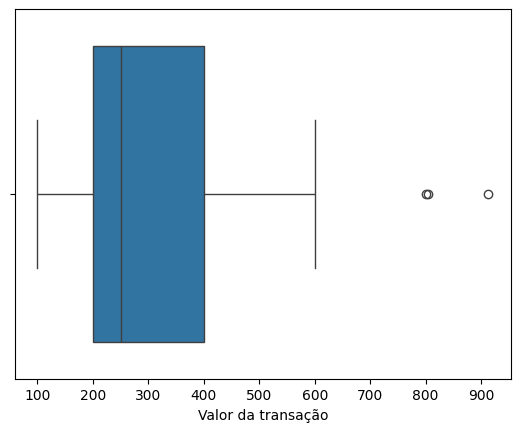

In [26]:
verficar_outlier(df,'Valor da transação')